---
title: Random Forest Hyperparameter Tuning
author: Andrei Akopian
date: 2025-10-06
format:
  html:
    code-fold: true
    code-summary: "Show the code"
  pdf:
    code-overflow: wrap
    echo: false
    output: true

---

# Random Forest Hyperparameter Tuning

Notion page: 

https://utat-ss.notion.site/Random-Forest-Hyperparameter-Tuning-2843e028b0ea80ff8d8bd341b8e7cda5

Note: some changes were done in 28th January in connection to writing a paper.

## Abstract

Report on testing the possibility of using Random Forest model to estimate npv, gv, and soil abundances from spectra as part of Unmixing effrots at UTAT Science. The analysis was done using Python with Pandas and Scikit-learn libraries on `simpler_data.csv` (no noise). Grid and Randomized searches (as well as manual) for tuning parameters were used. The results are disappointing. Random forest is prone to overfitting, and achieving a maximum of $r^2<0.74$ on all abundances, and $r^2<0.64$ for npv abundance only. Curiously, noise (snr=180) has only minor effects on random forest. Overall, Random Forest produces poor results and should be phased out.

## Background Information

Zoe previously performed major grid search trying to tune Random Forest ([see Notion](https://utat-ss.notion.site/FAE-RF-Random-Forest-1b63e028b0ea80e3afcad34492232512)). That search did not produce a model significantly different from Random and manual searches I performed.

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
import numpy as np

In [2]:
# Sys and self defs Imports
import sys
from pathlib import Path

github_root = Path.cwd().resolve().parents[1]
sys.path.append(str(github_root))

from src.utils import helper_functions

In [3]:
DATA_FILEPATH = "../../data/useful_columns_data.csv"

In [4]:
df = helper_functions.open_file(DATA_FILEPATH)
fractions, nr900to1700 = helper_functions.take_subset(df,start=900,end=1700)

## Manual Tuning
More details on rationale here: https://utat-ss.notion.site/Random-Forest-Hyperparameter-Tuning-2843e028b0ea80ff8d8bd341b8e7cda5

I manually checked the derivitives from minor changes in each parameters. I concluded that all parameters have a primitive effects and either have only one peak, or simply platoe. The parameters don't seem to have any interesting bonds or effects on each other's peak locations or predictions.

Best parameters:
```py
n_estimators=200,
max_depth=18,
max_features = 13,
min_samples_split=3,
min_samples_leaf=1,
min_impurity_decrease=0.0,
min_weight_fraction_leaf=0.0,
random_state = 42,
```

In [11]:
#| code-fold: false
#| echo: true
#| output: false
X_train, X_test, y_train, y_test = sklearn.model_selection.train_test_split(nr900to1700, fractions, test_size=0.5, random_state=42)
rf = sklearn.ensemble.RandomForestRegressor(
    n_estimators=200,
    max_depth=18,
    max_features = 13,
    min_samples_split=3,
    min_samples_leaf=1,
    min_impurity_decrease=0.0,
    min_weight_fraction_leaf=0.0,
    random_state = 42,
)
rf.fit(X_train, y_train)

,n_estimators,200
,criterion,'squared_error'
,max_depth,18
,min_samples_split,3
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,13
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


Random Fores overfits very severely, and in fact acts extremely conservatively.

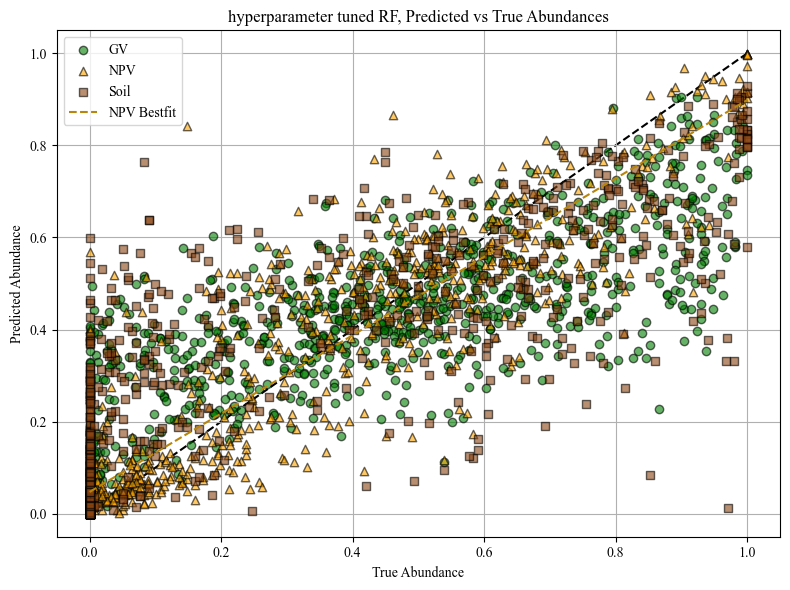

Training r^2: 0.956581060064185
Testing r^2: 0.6900685431852844


In [12]:
#| echo: true
#| output: true
helper_functions.plot_preds(
    ab_true = y_test.to_numpy(),
    ab_pred = rf.predict(X_test),
    save_path = "hyperparameter_tuned_rf.svg",
    model_name = "hyperparameter tuned RF"
)
print(f"Training r^2: {rf.score(X_train, y_train)}")
print(f"Testing r^2: {rf.score(X_test, y_test)}")

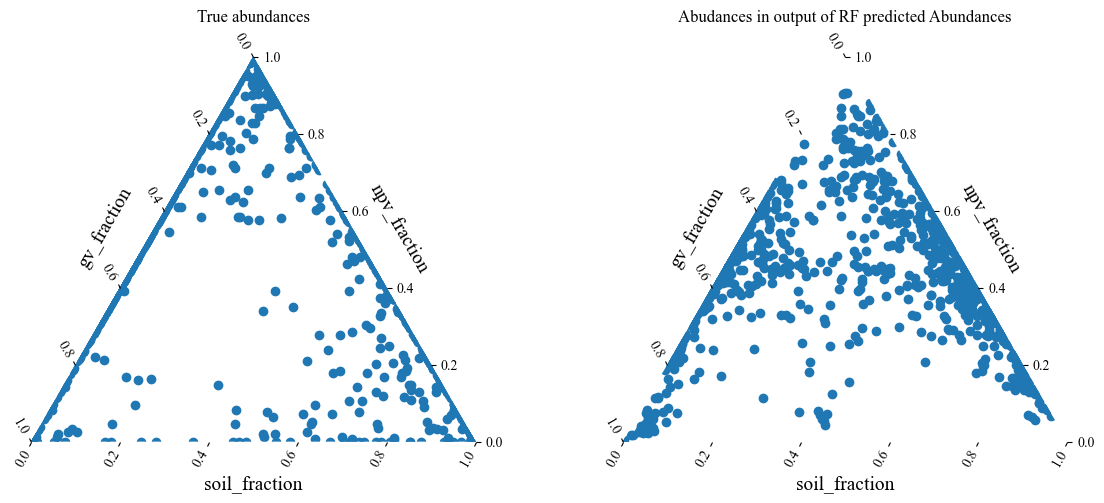

In [13]:
helper_functions.ternary_abundances(y_test, rf.predict(X_test), model_name="RF predicted Abundances")

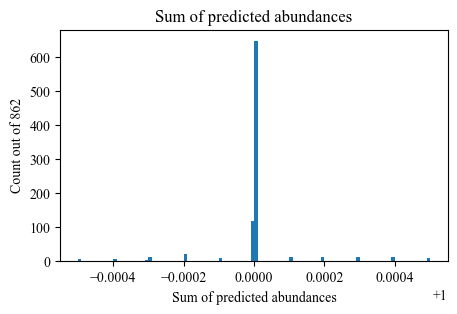

In [21]:
# | output: false
# | code-fold: true
ab_clipped_predictions = np.clip(y_test.to_numpy(), a_min=0, a_max=1)
helper_functions.simple_histogram(ab_clipped_predictions.sum(axis=1), title="Sum of predicted abundances", x_label="Sum of predicted abundances", y_label=f"Count out of {y_test.shape[0]}", bins=100)

In [8]:
#| echo: true
rf = sklearn.ensemble.RandomForestRegressor(
    n_estimators=200,
    max_depth=18,
    max_features = 13,
    min_samples_split=3,
    min_samples_leaf=1,
    min_impurity_decrease=0.0,
    min_weight_fraction_leaf=0.0,
    random_state = 42,
)
sklearn.model_selection.cross_val_score(rf, nr900to1700, fractions, cv=3)

array([0.38532766, 0.58596605, 0.54099535])

# Systematic Tuning

I mostly used RandomizedSearch for tuning, because it is faster than Grid Search, and random would quickly find symptoms of a good model, if one exists.

Unfortunately, RandomizedSearch found nothing that has potential to outperform my best manual model, so I never got to using grid search. 

Rough ranges I covered:
- `n_estimators` I tested 50 - 400, and >200 shows only minor improvements
- `max_depth` I tested 5 - 20, and 13-18 range seems to work th best, but nothing interesting
- `max_features` I checked the full range from 0.1 to 1 (fraction). But other than long runtime, nothing significant
- `min_samples_split` Checked 2 - 10 low is good for this, which aligns with my manual tuning.
- `min_samples_leaf` Checked 1 - 5, and 1 is the best
- `criterion` Checked criterions avaiable for Sklearn's model, and they all work about the same

In [10]:
#| echo: true
#| output: false
#| code-overflow: wrap
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [15, 16, 17, 20],
    'max_features': [0.4,0.6],
    'min_samples_split': [2,3],
    'min_samples_leaf': [1, 2, 3],
    'criterion': ['squared_error']
}
random_reg = sklearn.model_selection.RandomizedSearchCV(sklearn.ensemble.RandomForestRegressor(), param_grid, cv=5, n_jobs=-1, random_state=42)
random_reg.fit(train_X,train_y)

NameError: name 'train_X' is not defined

In [77]:
#| output: true
#| echo: true
random_reg.best_params_

{'n_estimators': 200,
 'min_samples_split': 3,
 'min_samples_leaf': 1,
 'max_features': 0.4,
 'max_depth': 17,
 'criterion': 'squared_error'}

In [ ]:
#| echo: true
# Validation of the tuning produced model
validate(random_reg,train_X,validate_X,train_y,validate_y)

Cross validation again shows variation, which reassures me that chasing minor changes in $r^2$ is pointless.

For `Validation R^2: 0.7331`
`array([0.7238703 , 0.72821315, 0.72174309, 0.69880877, 0.74258825])` (this is for all abundances)

In [ ]:
sklearn.model_selection.cross_val_score(random_reg.best_estimator_, train_X, train_y, cv=5, random_state=42)

### Manual after the Auto

I tried some manual tuning on all models produces by the computer. Manual tuning attempts confirmed that the computer is tuning for insignificant increases, and the searches and the found models didn't produce anything interesting.

In [15]:
rf2 = sklearn.ensemble.RandomForestRegressor(
    n_estimators=200,
    max_depth=18,
    max_features = 13,
    min_samples_split=3,
    min_samples_leaf=1,
    min_impurity_decrease=0.0,
    min_weight_fraction_leaf=0.0,
    random_state = 42,
)
rf2.fit(train_X, train_y)

,n_estimators,200
,criterion,'squared_error'
,max_depth,18
,min_samples_split,3
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,13
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [16]:
print(f"Training r^2: {rf2.score(X_train, y_train)}")
print(f"Testing r^2: {rf2.score(X_test, y_test)}")

Training r^2: 0.956581060064185
Testing r^2: 0.6900685431852844


Best model (other top models don't differ from it significantly):

```py
rf = sklearn.ensemble.RandomForestRegressor(
    n_estimators=200,
    max_depth=18,
    max_features = 13,
    min_samples_split=3,
    min_samples_leaf=1,
    min_impurity_decrease=0.0,
    min_weight_fraction_leaf=0.0,
    random_state = 42,
)
```